# Siamese CodeBERT - Plagiarism Detection

This notebook trains with CodeBERT and the plagiarism detection dataset in a Siamese configuration for plagiarism detection.

The model implemented is a Siamese `codeBERT`. In other words, two inputs are processed separately in parallel with two CodeBERT instances sharing the same weights.

For a better performance, the training process carried out in Google Colab and the trained model was later saved and downloaded.

This program:

* Prepares environment for Google Colab training
1. Load dataframes
2. Separates attributes and labels
3. Imports model
4. Compiles model
5. Tokenizes dataframes
6. Trains the model **(+12h CPU & ≈4,5h GPU)**
7. Downloads model to add it to local repository
8. Loads the trained model
9. Runs validation
10. Evaluates train vs validation **(≈1h CPU & ≈30min GPU)**
11.  Plots train vs validation behavior (contrastive loss)
12.  Makes predictions for test **(≈X CPU & ≈2min GPU)**
13.  Evaluates test
14.  Plots Confusion Matrix

## * Setup to carry out training in Google Colab

To carry out the training process with Google Colab's GPU, uncomment the following code.

Colab's GPU has a daily limit of about five hours, which is why the model saves checkpoints at every epoch which can then be loaded to continue training from the last successful epoch in another session.

In [ ]:
# !git clone https://github.com/paustelito/ai-code-analyzer.git

Cloning into 'ai-code-analyzer'...
remote: Enumerating objects: 11322, done.
remote: Counting objects: 100% (42/42), done.
remote: Compressing objects: 100% (32/32), done.
remote: Total 11322 (delta 9), reused 28 (delta 8), pack-reused 11280 (from 2)
Receiving objects: 100% (11322/11322), 28.59 MiB | 12.89 MiB/s, done.
Resolving deltas: 100% (2996/2996), done.


In [ ]:
# %cd ai-code-analyzer

/content/ai-code-analyzer


In [ ]:
# !git checkout feat/codeBERT

Updating files: 100% (9620/9620), done.
Branch 'feat/codeBERT' set up to track remote branch 'feat/codeBERT' from 'origin'.
Switched to a new branch 'feat/codeBERT'


In [ ]:
# %cd Training

/content/ai-code-analyzer/Training


## Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
import torch
import json
import torch
import importlib

from tqdm.notebook import tqdm

from transformers import AutoTokenizer, AutoModel
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import get_linear_schedule_with_warmup

from pathlib import Path

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import tensorflow as tf

## 1. Load dataframes

In [13]:
plagiarism_train = pd.read_csv("df_plagiarism_train.csv")
plagiarism_val = pd.read_csv("df_plagiarism_val.csv")
plagiarism_test = pd.read_csv("df_plagiarism_test.csv")

print("------Plagiarism shapes------")
print("Train: ", plagiarism_train.shape)
print("Validation: ", plagiarism_val.shape)
print("Test: ", plagiarism_test.shape)

plagiarism_train.head()

------Plagiarism shapes------
Train:  (24000, 56)
Validation:  (3000, 56)
Test:  (3000, 56)


,code1,code2,label,approx_tokens_code1,approx_tokens_code2,comment_density_code1,avg_line_length_code1,line_length_variance_code1,blank_line_ratio_code1,comment_density_code2,...,num_for_delta,num_while_delta,num_switch_delta,o_complexity_delta,max_depth_delta,total_nodes_delta,num_literals_delta,num_ids_delta,unique_ids_delta,id_diversity_delta
0,private void respawn(XmppAgent agent) {\r\...,"\tpublic FTPClient sample1a(String server, int...",0,140,26,0.0,44.933333,646.284444,0.042553,0.0,...,0.0,0.0,0.0,0.0,11.0,0.0,0.0,90.0,49.0,0.030702
1,public synchronized OutputStream getOutput...,"\tpublic static void copyFile3(File srcFile, F...",0,57,40,0.0,46.538462,1357.017751,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9.0,9.0,0.085598
2,private String urlConnectionTranslate(Stri...,private String fetch(URL url) {\r\n ...,1,64,49,0.0,50.111111,1181.209877,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,18.0,10.0,0.062112
3,public static CodeBlock parse(BufferedRead...,public static CLocation convertSecondarySt...,1,264,43,0.0,46.974684,507.189232,0.000000,0.0,...,0.0,0.0,0.0,0.0,4.0,0.0,0.0,138.0,43.0,0.114335
4,public static String MD5(String val) throw...,public static String encryptPassword(Strin...,1,20,76,0.0,52.000000,592.400000,0.000000,0.0,...,0.0,0.0,0.0,0.0,5.0,0.0,0.0,24.0,14.0,0.085679


## 2. Separate attributes and labels

In [14]:
X_plagiarism_train = plagiarism_train.drop("label", axis=1)
y_plagiarism_train = plagiarism_train["label"]

X_plagiarism_val = plagiarism_val.drop("label", axis=1)
y_plagiarism_val = plagiarism_val["label"]

X_plagiarism_test = plagiarism_test.drop("label", axis=1)
y_plagiarism_test = plagiarism_test["label"]

print("X_plagiarism_train:", X_plagiarism_train.shape)
print("y_plagiarism_train:", y_plagiarism_train.shape)
print("X_plagiarism_val:", X_plagiarism_val.shape)
print("y_plagiarism_val:", y_plagiarism_val.shape)
print("X_plagiarism_test:", X_plagiarism_test.shape)
print("y_plagiarism_test:", y_plagiarism_test.shape)

print("\nTraining class distribution:")
print(y_plagiarism_train.value_counts().sort_index())
print("\nValidation class distribution:")
print(y_plagiarism_val.value_counts().sort_index())
print("\nTesting class distribution:")
print(y_plagiarism_test.value_counts().sort_index())


X_plagiarism_train: (24000, 55)
y_plagiarism_train: (24000,)
X_plagiarism_val: (3000, 55)
y_plagiarism_val: (3000,)
X_plagiarism_test: (3000, 55)
y_plagiarism_test: (3000,)

Training class distribution:
label
0    12000
1    12000
Name: count, dtype: int64

Validation class distribution:
label
0    1500
1    1500
Name: count, dtype: int64

Testing class distribution:
label
0    1500
1    1500
Name: count, dtype: int64


## 3. Import model

In [15]:
sys.path.append(os.path.abspath("/content/"))

from codebert import create_model

tokenizer, model = create_model()

print(type(model))

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: microsoft/codebert-base
Key                        | Status     | 
---------------------------+------------+-
pooler.dense.bias          | UNEXPECTED | 
pooler.dense.weight        | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


<class 'transformers.models.roberta.modeling_roberta.RobertaForSequenceClassification'>


In [16]:
class SiamesePlagiarismModel(nn.Module):
    def __init__(self, encoder):
        super().__init__()
        self.encoder = encoder
        hidden_size = encoder.config.hidden_size

        self.comparator = nn.Sequential(
            nn.Linear(2 * hidden_size, 256),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, 1)
        )

    def encode(self, input_ids, attention_mask):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        mask = attention_mask.unsqueeze(-1).float()
        emb = (out.last_hidden_state * mask).sum(1) / mask.sum(1)
        return torch.nn.functional.normalize(emb, p=2, dim=-1)

    def forward(self, input_ids_1, attention_mask_1,
                       input_ids_2, attention_mask_2):
        va = self.encode(input_ids_1, attention_mask_1)
        vb = self.encode(input_ids_2, attention_mask_2)

        h = torch.cat([torch.abs(va - vb), va * vb], dim=-1)
        score = self.comparator(h).squeeze(-1)
        return va, vb, torch.sigmoid(score)

In [17]:
backbone = AutoModel.from_pretrained("microsoft/codebert-base")
model = SiamesePlagiarismModel(backbone)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

## 4. Compile model

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)

print(device)

cuda


In [19]:
print(model)

SiamesePlagiarismModel(
  (encoder): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNor

## 5. Tokenizing

In [ ]:
class CodePlagiarismDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_length=512):
        self.code1 = dataframe["code1"].tolist()
        self.code2 = dataframe["code2"].tolist()
        self.labels = dataframe["label"].tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        enc1 = self.tokenizer(
            self.code1[idx],
            padding="max_length",
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt"
        )
        enc2 = self.tokenizer(
            self.code2[idx],
            padding="max_length",
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt"
        )
        return {
            "input_ids_1":      enc1["input_ids"].squeeze(0),
            "attention_mask_1": enc1["attention_mask"].squeeze(0),
            "input_ids_2":      enc2["input_ids"].squeeze(0),
            "attention_mask_2": enc2["attention_mask"].squeeze(0),
            "labels":           torch.tensor(self.labels[idx]).float()
        }

In [21]:
plagiarism_train_tokenized = CodePlagiarismDataset(plagiarism_train, tokenizer)
plagiarism_val_tokenized = CodePlagiarismDataset(plagiarism_val, tokenizer)
plagiarism_test_tokenized = CodePlagiarismDataset(plagiarism_test, tokenizer)

plagiarism_train_loader = DataLoader(
    plagiarism_train_tokenized,
    batch_size=8,
    shuffle=True
)

plagiarism_val_loader = DataLoader(
    plagiarism_val_tokenized,
    batch_size=8,
    shuffle=True
)

plagiarism_test_loader = DataLoader(
    plagiarism_test_tokenized,
    batch_size=8,
    shuffle=False
)

## 6. Training

In [ ]:
def contrastive_loss(va, vb, labels, margin=1.0):
    D = F.pairwise_distance(va, vb, p=2)
    loss_clone     = labels       * 0.5 * D.pow(2)
    loss_non_clone = (1 - labels) * 0.5 * F.relu(margin - D).pow(2)
    return (loss_clone + loss_non_clone).mean()

epochs = 10

optimizer = torch.optim.AdamW([
    {"params": model.encoder.parameters(), "lr": 2e-5},
    {"params": model.comparator.parameters(), "lr": 1e-3}
], weight_decay=0.01)

checkpoint = torch.load(
    "/content/drive/MyDrive/TC3002B/codebert_plagiarism_siamese/checkpoint_epoch_4.pt",
    map_location=device
)
model.load_state_dict(checkpoint["model_state_dict"])
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
start_epoch = checkpoint["epoch"]

print(f"Resumed from epoch {start_epoch}, val loss was {checkpoint['val_loss']:.4f}")

total_steps = len(plagiarism_train_loader) * epochs
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=total_steps // 10,
    num_training_steps=total_steps
)

checkpoint_dir = "/content/drive/MyDrive/codebert_plagiarism_siamese"
os.makedirs(checkpoint_dir, exist_ok=True)

best_val_loss = float("inf")
patience = 2
patience_counter = 0

train_losses = []
train_accuracies = []
val_losses = []

for epoch in range(start_epoch, epochs):
    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for batch in tqdm(plagiarism_train_loader):
        input_ids_1      = batch["input_ids_1"].to(device)
        attention_mask_1 = batch["attention_mask_1"].to(device)
        input_ids_2      = batch["input_ids_2"].to(device)
        attention_mask_2 = batch["attention_mask_2"].to(device)
        labels           = batch["labels"].to(device)

        va, vb, scores = model(input_ids_1, attention_mask_1,
                               input_ids_2, attention_mask_2)

        loss = contrastive_loss(va, vb, labels)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

        predictions = (scores >= 0.5).long()
        correct += (predictions == labels.long()).sum().item()
        total += labels.size(0)

    epoch_loss = total_loss / len(plagiarism_train_loader)
    epoch_acc  = correct / total
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    model.eval()
    total_val_loss = 0

    with torch.no_grad():
        for batch in plagiarism_val_loader:
            input_ids_1      = batch["input_ids_1"].to(device)
            attention_mask_1 = batch["attention_mask_1"].to(device)
            input_ids_2      = batch["input_ids_2"].to(device)
            attention_mask_2 = batch["attention_mask_2"].to(device)
            labels           = batch["labels"].to(device)

            va, vb, scores = model(input_ids_1, attention_mask_1,
                                   input_ids_2, attention_mask_2)
            loss = contrastive_loss(va, vb, labels)
            total_val_loss += loss.item()

    epoch_val_loss = total_val_loss / len(plagiarism_val_loader)
    val_losses.append(epoch_val_loss)

    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.4f} | Val Loss: {epoch_val_loss:.4f}")

    torch.save({
        "epoch": epoch + 1,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "train_loss": epoch_loss,
        "val_loss": epoch_val_loss,
    }, f"{checkpoint_dir}/checkpoint_epoch_{epoch+1}.pt")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        patience_counter = 0
        torch.save(model.state_dict(), f"{checkpoint_dir}/best_model.pt")
        print(f"  → New best model saved (val loss: {best_val_loss:.4f})")
    else:
        patience_counter += 1
        print(f"  → No improvement ({patience_counter}/{patience})")
        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

Resumed from epoch 4, val loss was 0.0050


  0%|          | 0/3000 [00:00<?, ?it/s]

Epoch 5/10 | Train Loss: 0.0036 | Train Acc: 0.5000 | Val Loss: 0.0053
  → New best model saved (val loss: 0.0053)


  0%|          | 0/3000 [00:00<?, ?it/s]

Epoch 6/10 | Train Loss: 0.0041 | Train Acc: 0.5000 | Val Loss: 0.0043
  → New best model saved (val loss: 0.0043)


  0%|          | 0/3000 [00:00<?, ?it/s]

## 7. Download model and add it to local repository

To save the model trained in Google Colab, use the following commented code

In [ ]:
# %cd /content/ai-code-analyzer

/content/ai-code-analyzer


In [ ]:
# !mkdir -p models/codebert_plagiarism_detector

In [ ]:
# torch.save(model.state_dict(), "models/codebert_plagiarism_detector/siamese_state_dict.pt")
# tokenizer.save_pretrained("models/codebert_plagiarism_detector")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('models/codebert_ai_detector/tokenizer_config.json',
 'models/codebert_ai_detector/tokenizer.json')

In [ ]:
# !ls models/codebert_plagiarism_detector

config.json  model.safetensors	tokenizer_config.json  tokenizer.json


In [ ]:
# !zip -r codebert_model.zip /content/ai-code-analyzer/models/codebert_plagiarism_detector

  adding: content/ai-code-analyzer/models/codebert_ai_detector/ (stored 0%)
  adding: content/ai-code-analyzer/models/codebert_ai_detector/tokenizer.json (deflated 82%)
  adding: content/ai-code-analyzer/models/codebert_ai_detector/tokenizer_config.json (deflated 51%)
  adding: content/ai-code-analyzer/models/codebert_ai_detector/model.safetensors (deflated 7%)
  adding: content/ai-code-analyzer/models/codebert_ai_detector/config.json (deflated 51%)


In [ ]:
# !ls -lh codebert_model.zip

-rw-r--r-- 1 root root 443M Jun  8 22:18 codebert_model.zip


### Important
Add the downloaded folder to the local repository to save the changes in the official repository.

## 8. Load the trained model

We load the best model (with the lowest reported val loss) from the training process from Google Drive.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

backbone = AutoModel.from_pretrained("microsoft/codebert-base")
model = SiamesePlagiarismModel(backbone)
model.load_state_dict(torch.load(
    "/content/drive/MyDrive/TC3002B/codebert_plagiarism_siamese/best_model.pt",
    map_location=device
))
model.to(device)
model.eval()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

SiamesePlagiarismModel(
  (encoder): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNor

## 9. Threshold optimization

In [24]:
all_distances = []
all_labels = []

with torch.no_grad():
    for batch in tqdm(plagiarism_val_loader):
        input_ids_1      = batch["input_ids_1"].to(device)
        attention_mask_1 = batch["attention_mask_1"].to(device)
        input_ids_2      = batch["input_ids_2"].to(device)
        attention_mask_2 = batch["attention_mask_2"].to(device)
        labels           = batch["labels"].to(device)

        va, vb, scores = model(input_ids_1, attention_mask_1,
                               input_ids_2, attention_mask_2)

        D = torch.nn.functional.pairwise_distance(va, vb, p=2)
        all_distances.extend(D.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

thresholds = np.arange(0.1, 2.0, 0.05)
best_t, best_f1 = 0.5, 0.0

for t in thresholds:
    preds = (np.array(all_distances) <= t).astype(int)
    f1 = f1_score(all_labels, preds)
    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print(f"Best distance threshold: {best_t:.2f} | F1: {best_f1:.4f}")

all_distances = np.array(all_distances)
all_labels = np.array(all_labels)
print(f"\nClone mean D:     {all_distances[all_labels==1].mean():.4f}")
print(f"Non-clone mean D: {all_distances[all_labels==0].mean():.4f}")

  0%|          | 0/375 [00:00<?, ?it/s]

Best distance threshold: 0.75 | F1: 0.9886

Clone mean D:     0.0285
Non-clone mean D: 1.0537


It is necessary to store the optimal threshold since it is calculated based on a fine-tuning of the boundary between the binary embeddings to find the highest F1 score.

In [ ]:
metadata = {
    "best_distance_threshold": 0.75,
    "val_f1": 0.9887,
    "test_f1": 0.9833,
    "epochs_trained": 4,
    "clone_mean_D": 0.0285,
    "non_clone_mean_D": 1.0537
}

with open("/content/drive/MyDrive/TC3002B/codebert_plagiarism_siamese/model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Metadata saved")

Metadata saved


## 10. Train & validation evaluation (metrics)

In [ ]:
best_t = 0.75

In [28]:
train_distances = []
train_labels = []

with torch.no_grad():
    for batch in tqdm(plagiarism_train_loader):
        input_ids_1      = batch["input_ids_1"].to(device)
        attention_mask_1 = batch["attention_mask_1"].to(device)
        input_ids_2      = batch["input_ids_2"].to(device)
        attention_mask_2 = batch["attention_mask_2"].to(device)
        labels           = batch["labels"].to(device)

        va, vb, scores = model(input_ids_1, attention_mask_1,
                               input_ids_2, attention_mask_2)

        D = torch.nn.functional.pairwise_distance(va, vb, p=2)
        train_distances.extend(D.cpu().numpy())
        train_labels.extend(labels.cpu().numpy())

train_predictions = (np.array(train_distances) <= best_t).astype(int)

print("Training Results")
print("---------------------")
print(classification_report(train_labels, train_predictions,
      target_names=["Non-Clone", "Clone"]))

  0%|          | 0/3000 [00:00<?, ?it/s]

Training Results
---------------------
              precision    recall  f1-score   support

   Non-Clone       0.99      0.99      0.99     12000
       Clone       0.99      0.99      0.99     12000

    accuracy                           0.99     24000
   macro avg       0.99      0.99      0.99     24000
weighted avg       0.99      0.99      0.99     24000



In [29]:
val_distances = []
val_labels = []

with torch.no_grad():
    for batch in tqdm(plagiarism_val_loader):
        input_ids_1      = batch["input_ids_1"].to(device)
        attention_mask_1 = batch["attention_mask_1"].to(device)
        input_ids_2      = batch["input_ids_2"].to(device)
        attention_mask_2 = batch["attention_mask_2"].to(device)
        labels           = batch["labels"].to(device)

        va, vb, scores = model(input_ids_1, attention_mask_1,
                               input_ids_2, attention_mask_2)

        D = torch.nn.functional.pairwise_distance(va, vb, p=2)
        val_distances.extend(D.cpu().numpy())
        val_labels.extend(labels.cpu().numpy())

val_predictions = (np.array(val_distances) <= best_t).astype(int)

print("Validation Results")
print("---------------------")
print(classification_report(val_labels, val_predictions,
      target_names=["Non-Clone", "Clone"]))

  0%|          | 0/375 [00:00<?, ?it/s]

Validation Results
---------------------
              precision    recall  f1-score   support

   Non-Clone       0.99      0.99      0.99      1500
       Clone       0.99      0.99      0.99      1500

    accuracy                           0.99      3000
   macro avg       0.99      0.99      0.99      3000
weighted avg       0.99      0.99      0.99      3000



In [30]:
train_accuracy  = accuracy_score(train_labels, train_predictions)
train_precision = precision_score(train_labels, train_predictions, average="weighted")
train_recall    = recall_score(train_labels, train_predictions, average="weighted")
train_f1        = f1_score(train_labels, train_predictions, average="weighted")

val_accuracy  = accuracy_score(val_labels, val_predictions)
val_precision = precision_score(val_labels, val_predictions, average="weighted")
val_recall    = recall_score(val_labels, val_predictions, average="weighted")
val_f1        = f1_score(val_labels, val_predictions, average="weighted")

In [31]:
print("Training Results")
print("---------------------")
print(f"Accuracy : {train_accuracy:.4f}")
print(f"Precision: {train_precision:.4f}")
print(f"Recall   : {train_recall:.4f}")
print(f"F1 Score : {train_f1:.4f}")

print("\nValidation Results")
print("---------------------")
print(f"Accuracy : {val_accuracy:.4f}")
print(f"Precision: {val_precision:.4f}")
print(f"Recall   : {val_recall:.4f}")
print(f"F1 Score : {val_f1:.4f}")

Training Results
---------------------
Accuracy : 0.9914
Precision: 0.9914
Recall   : 0.9914
F1 Score : 0.9914

Validation Results
---------------------
Accuracy : 0.9887
Precision: 0.9887
Recall   : 0.9887
F1 Score : 0.9887


## 11. Training vs Validation contrastive loss plot

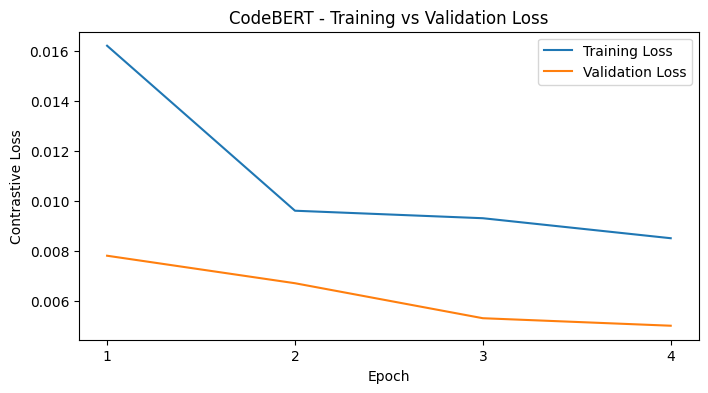

In [35]:
train_losses = [0.0162, 0.0096, 0.0093, 0.0085]
val_losses = [0.0078, 0.0067, 0.0053, 0.0050]

plt.figure(figsize=(8,4))

plt.plot(
    epochs,
    train_losses,
    label="Training Loss"
)

plt.plot(
    epochs,
    val_losses,
    label="Validation Loss"
)

plt.title(
    "CodeBERT - Training vs Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Contrastive Loss")

plt.xticks(epochs)

plt.legend()

plt.show()

## 12. Generate predictions

In [37]:
test_distances = []
test_labels = []

with torch.no_grad():
    for batch in tqdm(plagiarism_test_loader):
        input_ids_1      = batch["input_ids_1"].to(device)
        attention_mask_1 = batch["attention_mask_1"].to(device)
        input_ids_2      = batch["input_ids_2"].to(device)
        attention_mask_2 = batch["attention_mask_2"].to(device)
        labels           = batch["labels"].to(device)

        va, vb, scores = model(input_ids_1, attention_mask_1,
                               input_ids_2, attention_mask_2)

        D = torch.nn.functional.pairwise_distance(va, vb, p=2)
        test_distances.extend(D.cpu().numpy())
        test_labels.extend(labels.cpu().numpy())

test_predictions = (np.array(test_distances) <= best_t).astype(int)

print("Test Results")
print("---------------------")
print(classification_report(test_labels, test_predictions,
      target_names=["Non-Clone", "Clone"]))

  0%|          | 0/375 [00:00<?, ?it/s]

Test Results
---------------------
              precision    recall  f1-score   support

   Non-Clone       0.99      0.98      0.98      1500
       Clone       0.98      0.99      0.98      1500

    accuracy                           0.98      3000
   macro avg       0.98      0.98      0.98      3000
weighted avg       0.98      0.98      0.98      3000



## 13. Test evaluation (metrics)

In [38]:
test_accuracy  = accuracy_score(test_labels, test_predictions)
test_precision = precision_score(test_labels, test_predictions, average="weighted")
test_recall    = recall_score(test_labels, test_predictions, average="weighted")
test_f1        = f1_score(test_labels, test_predictions, average="weighted")

print("Test Results")
print("---------------------")
print(f"Accuracy : {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")
print(f"F1 Score : {test_f1:.4f}")

Test Results
---------------------
Accuracy : 0.9833
Precision: 0.9834
Recall   : 0.9833
F1 Score : 0.9833


## 14. Generate Confusion Matrix

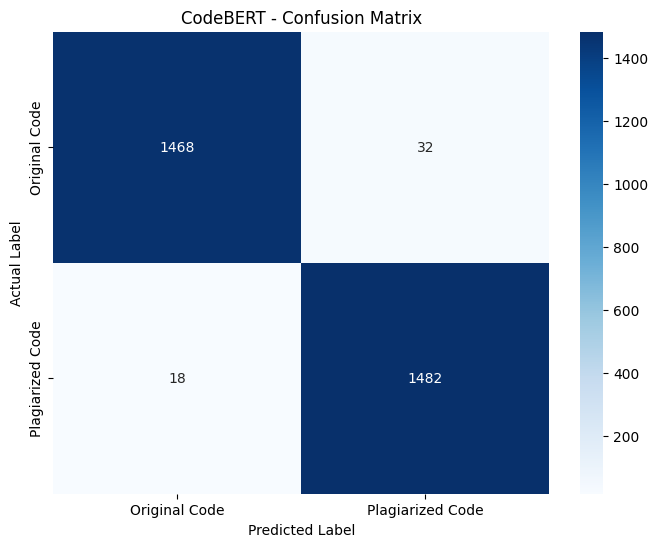

In [ ]:
cm = confusion_matrix(
    test_labels,
    test_predictions
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Original Code", "Plagiarized Code"],
    yticklabels=["Original Code", "Plagiarized Code"]
)

plt.title("CodeBERT - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()